In [3]:
from pathlib import Path
import numpy as np
import yaml

root = Path("../../../Datasets/Weibo2014/original")

npz_files = sorted(root.rglob("*.npz"))
yml_files = sorted(root.rglob("*.yml"))

print("NPZ files:", len(npz_files))
print("YAML files:", len(yml_files))

for f in npz_files[:10]:
    print(f)

NPZ files: 10
YAML files: 10
../../../Datasets/Weibo2014/original/Weibo2014/discarded/subject_04_session_01.npz
../../../Datasets/Weibo2014/original/Weibo2014/subject_01_session_01.npz
../../../Datasets/Weibo2014/original/Weibo2014/subject_02_session_01.npz
../../../Datasets/Weibo2014/original/Weibo2014/subject_03_session_01.npz
../../../Datasets/Weibo2014/original/Weibo2014/subject_05_session_01.npz
../../../Datasets/Weibo2014/original/Weibo2014/subject_06_session_01.npz
../../../Datasets/Weibo2014/original/Weibo2014/subject_07_session_01.npz
../../../Datasets/Weibo2014/original/Weibo2014/subject_08_session_01.npz
../../../Datasets/Weibo2014/original/Weibo2014/subject_09_session_01.npz
../../../Datasets/Weibo2014/original/Weibo2014/subject_10_session_01.npz


In [11]:
from pathlib import Path
import numpy as np
import yaml

root = Path("../../../Datasets/Weibo2014/original/Weibo2014")

npz_files = sorted([
    f for f in root.glob("*.npz")
])

yml_files = sorted([
    f for f in root.glob("*.yml")
])

print("Usable NPZ files:", len(npz_files))
print("Usable YAML files:", len(yml_files))

for f in npz_files:
    print(f.name)

Usable NPZ files: 10
Usable YAML files: 10
subject_01_session_01.npz
subject_02_session_01.npz
subject_03_session_01.npz
subject_04_session_01.npz
subject_05_session_01.npz
subject_06_session_01.npz
subject_07_session_01.npz
subject_08_session_01.npz
subject_09_session_01.npz
subject_10_session_01.npz


In [5]:
file_path = npz_files[0]

data = np.load(file_path, allow_pickle=True)

print("File:", file_path.name)
print("Keys:", data.files)

for key in data.files:
    value = data[key]

    print(
        key,
        "| shape:", getattr(value, "shape", None),
        "| dtype:", getattr(value, "dtype", None)
    )

File: subject_01_session_01.npz
Keys: ['data', 'stim']
data | shape: (896000, 60) | dtype: float32
stim | shape: (896000,) | dtype: int16


In [6]:
yml_path = file_path.with_suffix(".yml")

with open(yml_path, "r") as f:
    metadata = yaml.safe_load(f)

metadata

{'acquisition': {'filter': 'Bandpass [0.1-100 Hz], Notch 50 Hz',
  'ground': 'Prefrontal lobe',
  'hardware': 'Neuroscan SynAmps2',
  'reference': 'Nose',
  'samplingrate': 200,
  'sensors': ['Fp1',
   'Fpz',
   'Fp2',
   'AF3',
   'AF4',
   'F7',
   'F5',
   'F3',
   'F1',
   'Fz',
   'F2',
   'F4',
   'F6',
   'F8',
   'FT7',
   'FC5',
   'FC3',
   'FC1',
   'FCz',
   'FC2',
   'FC4',
   'FC6',
   'FT8',
   'T7',
   'C5',
   'C3',
   'C1',
   'Cz',
   'C2',
   'C4',
   'C6',
   'T8',
   'TP7',
   'CP5',
   'CP3',
   'CP1',
   'CPz',
   'CP2',
   'CP4',
   'CP6',
   'TP8',
   'P7',
   'P5',
   'P3',
   'P1',
   'Pz',
   'P2',
   'P4',
   'P6',
   'P8',
   'PO7',
   'PO5',
   'PO3',
   'POz',
   'PO4',
   'PO6',
   'PO8',
   'O1',
   'Oz',
   'O2'],
  'sensortype': 'Ag/AgCl Wet electrodes',
  'software': 'eConnectome, Matlab'},
 'documentation': {'description': 'https://neurotechx.github.io/moabb/generated/moabb.datasets.Weibo2014.html#moabb.datasets.Weibo2014',
  'doi': 'https://doi.o

In [7]:
import pprint

pprint.pp(metadata)

{'acquisition': {'filter': 'Bandpass [0.1-100 Hz], Notch 50 Hz',
                 'ground': 'Prefrontal lobe',
                 'hardware': 'Neuroscan SynAmps2',
                 'reference': 'Nose',
                 'samplingrate': 200,
                 'sensors': ['Fp1',
                             'Fpz',
                             'Fp2',
                             'AF3',
                             'AF4',
                             'F7',
                             'F5',
                             'F3',
                             'F1',
                             'Fz',
                             'F2',
                             'F4',
                             'F6',
                             'F8',
                             'FT7',
                             'FC5',
                             'FC3',
                             'FC1',
                             'FCz',
                             'FC2',
                             'FC4',
               

In [8]:
for key in data.files:
    value = data[key]

    print(f"\n--- {key} ---")

    if np.ndim(value) == 0:
        print(value)
    else:
        print("Shape:", value.shape)
        print("First values:")
        print(value.flat[:20])


--- data ---
Shape: (896000, 60)
First values:
[-154.84651   -47.181488 -182.55077  -362.312     -74.26712   -95.69515
  -65.675095  -59.113396  -15.316691  -51.23255   -26.952007    9.833495
   24.022879   -2.970988   46.856342   16.282852   59.139095   -9.977617
   -4.872892   94.10875 ]

--- stim ---
Shape: (896000,)
First values:
[2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [9]:
print("ID:")
print(metadata["id"])

print("\nStimulus information:")
print(metadata["stim"])

print("\nUnique stim values:")
values, counts = np.unique(data["stim"], return_counts=True)

for value, count in zip(values, counts):
    print(value, count)

ID:
{'condition': 'None', 'database': 'Weibo2014', 'paradigm': 'MI', 'run': 1, 'session': 1, 'subject': 1, 'timestamp': 2014}

Stimulus information:
{'labels': {'left_hand': 1, 'right_hand': 2, 'feet': 3, 'rest': 4, 'both_hands': 5}, 'nclasses': 5, 'trials_per_class': {'right_hand': 80, 'both_hands': 80, 'left_hand': 80, 'feet': 80, 'rest': 80}, 'offset': 600, 'windowlength': 800}

Unique stim values:
0 895600
1 80
2 80
3 80
4 80
5 80


In [10]:
stim = data["stim"]

event_samples = np.where(stim != 0)[0]
event_labels = stim[event_samples]

print("Number of events:", len(event_samples))
print("First event samples:", event_samples[:20])
print("First event labels:", event_labels[:20])

print("\nEvent label counts:")
print(np.unique(event_labels, return_counts=True))

Number of events: 400
First event samples: [    0  1600  4800  6400  8000  9600 11200 12800 14400 16000 17600 19200
 20800 22400 25600 28800 30400 32000 35200 43200]
First event labels: [2 5 3 3 5 2 2 1 5 1 1 5 1 3 1 3 5 3 1 5]

Event label counts:
(array([1, 2, 3, 4, 5], dtype=int16), array([80, 80, 80, 80, 80]))


# Analysis

In [12]:
import mne
import numpy as np
import yaml
from pathlib import Path


root = Path("../../../Datasets/Weibo2014/original/Weibo2014")


# ----------------------------------------
# Load one Weibo subject/session
# ----------------------------------------

def load_weibo_recording(npz_path):
    
    npz_path = Path(npz_path)
    yml_path = npz_path.with_suffix(".yml")

    # Load signal + stimulus
    npz = np.load(npz_path)
    data = npz["data"]          # (samples, channels)
    stim = npz["stim"]          # (samples,)

    # Load metadata
    with open(yml_path, "r") as f:
        metadata = yaml.safe_load(f)

    sfreq = metadata["acquisition"]["samplingrate"]
    ch_names = metadata["acquisition"]["sensors"]

    # MNE expects (channels, samples)
    # Dataset values are in µV -> convert to V
    eeg = data.T * 1e-6

    info = mne.create_info(
        ch_names=ch_names,
        sfreq=sfreq,
        ch_types="eeg"
    )

    raw = mne.io.RawArray(
        eeg,
        info,
        verbose=False
    )

    raw.set_montage(
        "standard_1005",
        on_missing="ignore",
        verbose=False
    )

    # Events are indicated by non-zero stim values
    event_samples = np.where(stim != 0)[0]

    events = np.column_stack([
        event_samples,
        np.zeros(len(event_samples), dtype=int),
        stim[event_samples]
    ]).astype(int)

    return raw, events, metadata

In [13]:
subject_file = root / "subject_01_session_01.npz"

raw, events, metadata = load_weibo_recording(subject_file)

print(raw)

print("\nSampling rate:")
print(raw.info["sfreq"])

print("\nNumber of channels:")
print(len(raw.ch_names))

print("\nDuration:")
print(raw.times[-1], "seconds")

print("\nChannels:")
print(raw.ch_names)

print("\nEvents shape:")
print(events.shape)

print("\nFirst events:")
print(events[:10])

<RawArray | 60 x 896000 (4480.0 s), ~410.2 MiB, data loaded>

Sampling rate:
200.0

Number of channels:
60

Duration:
4479.995 seconds

Channels:
['Fp1', 'Fpz', 'Fp2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POz', 'PO4', 'PO6', 'PO8', 'O1', 'Oz', 'O2']

Events shape:
(400, 3)

First events:
[[    0     0     2]
 [ 1600     0     5]
 [ 4800     0     3]
 [ 6400     0     3]
 [ 8000     0     5]
 [ 9600     0     2]
 [11200     0     2]
 [12800     0     1]
 [14400     0     5]
 [16000     0     1]]


In [14]:
label_map = metadata["stim"]["labels"]

print("Original label mapping:")
print(label_map)

print("\nEvent counts:")

event_codes, counts = np.unique(
    events[:, 2],
    return_counts=True
)

for code, count in zip(event_codes, counts):

    label = next(
        name for name, value in label_map.items()
        if value == code
    )

    print(
        f"{code}: {label:<12} -> {count} trials"
    )

Original label mapping:
{'left_hand': 1, 'right_hand': 2, 'feet': 3, 'rest': 4, 'both_hands': 5}

Event counts:
1: left_hand    -> 80 trials
2: right_hand   -> 80 trials
3: feet         -> 80 trials
4: rest         -> 80 trials
5: both_hands   -> 80 trials


In [15]:
# ----------------------------------------
# Extract left / right / feet trials
# ----------------------------------------

def extract_weibo_trials(raw, events, metadata):

    sfreq = metadata["acquisition"]["samplingrate"]

    offset = metadata["stim"]["offset"]
    windowlength = metadata["stim"]["windowlength"]

    labels = metadata["stim"]["labels"]

    # Common classes used in our benchmark
    class_map = {
        labels["left_hand"]: 0,
        labels["right_hand"]: 1,
        labels["feet"]: 2
    }

    raw_data = raw.get_data()

    X_all = []
    y_all = []

    for sample, _, code in events:

        if code not in class_map:
            continue

        start = sample + offset
        end = start + windowlength

        trial = raw_data[:, start:end]

        # Make sure trial has expected length
        if trial.shape[1] != windowlength:
            continue

        X_all.append(trial)
        y_all.append(class_map[code])

    X = np.stack(X_all)
    y = np.asarray(y_all)

    return X, y

In [16]:
X, y = extract_weibo_trials(
    raw,
    events,
    metadata
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print(
    "Class distribution:",
    np.unique(y, return_counts=True)
)

X shape: (240, 60, 800)
y shape: (240,)
Class distribution: (array([0, 1, 2]), array([80, 80, 80]))


In [17]:
sfreq = raw.info["sfreq"]

print("Sampling rate:", sfreq, "Hz")
print("Samples per trial:", X.shape[-1])
print("Trial duration:", X.shape[-1] / sfreq, "seconds")

print(
    "Dataset offset:",
    metadata["stim"]["offset"] / sfreq,
    "seconds"
)

Sampling rate: 200.0 Hz
Samples per trial: 800
Trial duration: 4.0 seconds
Dataset offset: 3.0 seconds


In [18]:
info = raw.info.copy()

epoch_events = np.zeros(
    (len(y), 3),
    dtype=int
)

epoch_events[:, 0] = np.arange(len(y))
epoch_events[:, 2] = y + 1

event_id = {
    "left_hand": 1,
    "right_hand": 2,
    "feet": 3
}

epochs = mne.EpochsArray(
    X,
    info,
    events=epoch_events,
    event_id=event_id,
    tmin=0.0,
    verbose=False
)

print(epochs)

<EpochsArray | 240 events (all good), 0 – 3.995 s (baseline off), ~88.0 MiB, data loaded,
 'left_hand': 80
 'right_hand': 80
 'feet': 80>


    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/Users/edsonodake/miniforge3/envs/svm_env/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


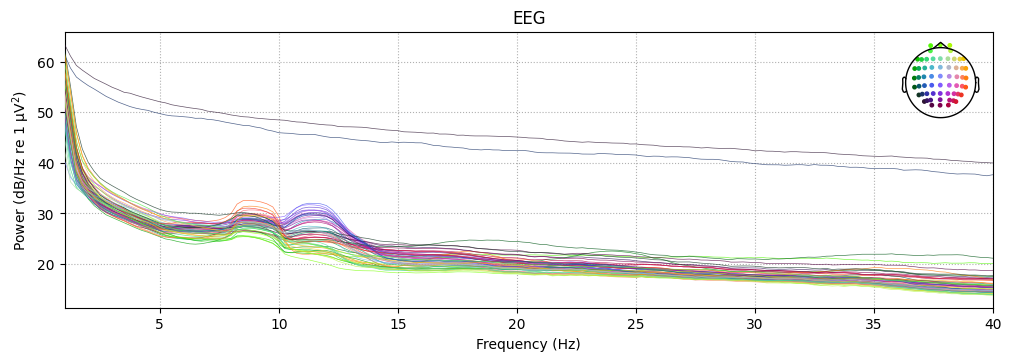

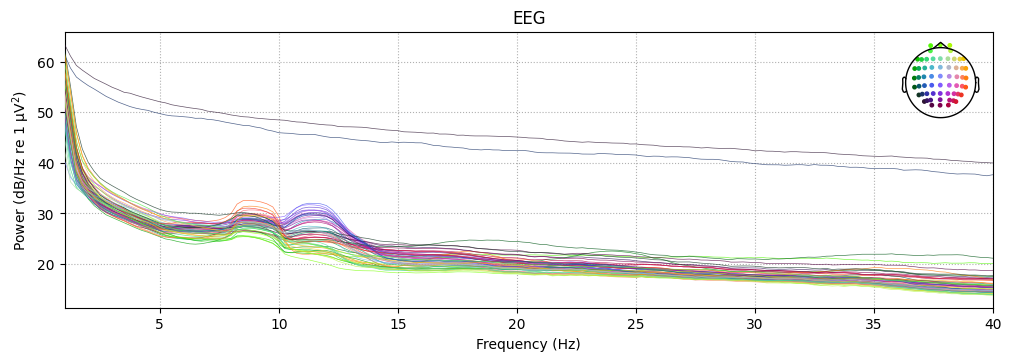

In [19]:
epochs.compute_psd(
    fmin=1,
    fmax=40
).plot()

Effective window size : 10.240 (s)
Plotting power spectral density (dB=True).


/Users/edsonodake/miniforge3/envs/svm_env/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


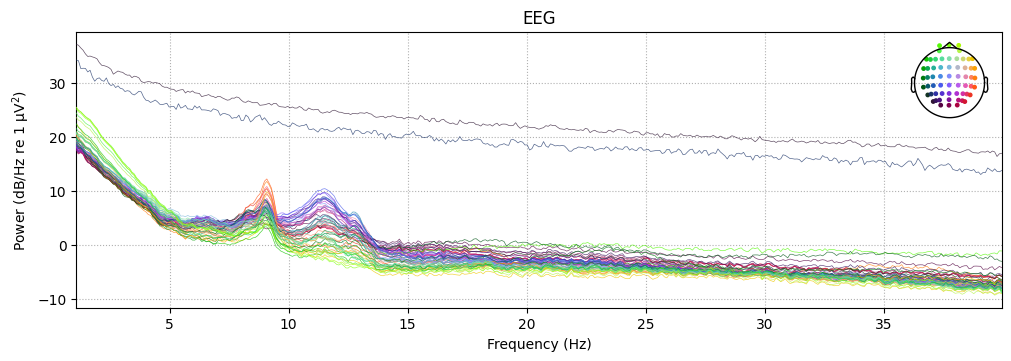

In [20]:
raw.compute_psd(
    fmin=1,
    fmax=40
).plot()

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/Users/edsonodake/miniforge3/envs/svm_env/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


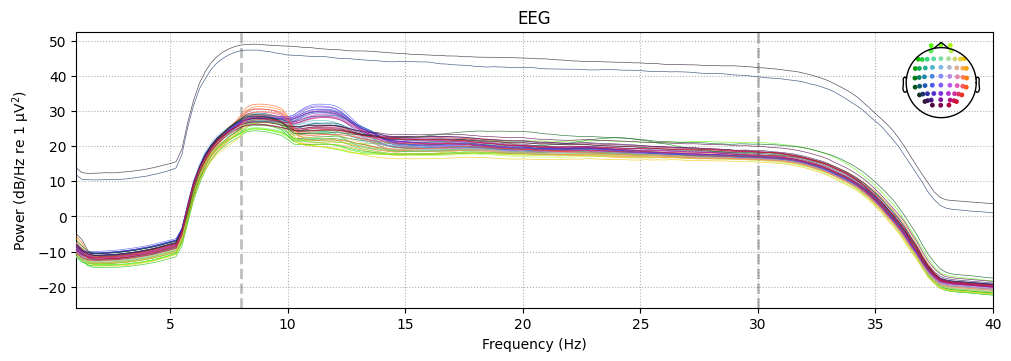

In [21]:
epochs_filtered = epochs.copy()

epochs_filtered.filter(
    8.0,
    30.0,
    fir_design="firwin",
    verbose=False
)

epochs_filtered.compute_psd(
    fmin=1,
    fmax=40
).plot()

In [22]:
print(epochs_filtered.ch_names)

['Fp1', 'Fpz', 'Fp2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POz', 'PO4', 'PO6', 'PO8', 'O1', 'Oz', 'O2']
